# PBMC 10k: fewer misclustered cells with scFair

This tutorial compares **standard HVG** and **scFair** on a labeled
**10x Genomics PBMC 10k (v3)** object, then asks a practical question:

> With the same downstream clustering recipe, how many cells end up in the
> **wrong cluster** relative to the gold cell-type labels?

Pipeline (identical except the HVG step):

1. Select HVGs — standard (`balance_method="none"`, top 2000) vs scFair append
   (top 2000 + 200 near-miss genes)
2. Normalize → log1p → scale → PCA → neighbors → **Leiden** → UMAP
3. Map each Leiden cluster to a gold label (majority vote) and count
   **misclustered cells** (predicted label ≠ gold `cell_type`)

UMAP is shown for context; the headline metric is the error count.


## Data (gold labels)

Labeled 10x PBMC 10k Chromium 3' v3 (~10.6k cells) with raw counts in
`layers["counts"]` and gold `cell_type` (8 populations, including smaller ones
such as DC and platelets).

```text
examples/data/pbmc_10k_v3_labeled.h5ad
```

This file is not on PyPI. Public counts: [10x Genomics](https://www.10xgenomics.com/datasets).


In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scfair as scf
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)

DATA = Path("../../examples/data/pbmc_10k_v3_labeled.h5ad")
if not DATA.exists():
    DATA = Path("examples/data/pbmc_10k_v3_labeled.h5ad")

adata0 = ad.read_h5ad(DATA)
if "counts" in adata0.layers:
    adata0.X = adata0.layers["counts"].copy()

print(adata0)
print(adata0.obs["cell_type"].value_counts().to_string())
print("scfair", scf.__version__)


/tmp/ipykernel_1818804/3583498929.py:12: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)


AnnData object with n_obs × n_vars = 10638 × 20136
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'marker_label'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'chemistry', 'dataset_id', 'label_source'
    layers: 'counts'
cell_type
CD4_T          3283
Mono_CD14      3251
B              1522
CD8_T          1133
NK              592
Mono_FCGR3A     376
DC              312
Platelet        169
scfair 0.5.0


## Shared downstream recipe

Only `balance_method` changes. Leiden resolution is fixed so both methods get
the same clustering settings (not tuned separately per method).


In [2]:
RESOLUTION = 0.5  # fixed for both methods
RANDOM_STATE = 0
N_TOP = 2000


def run_pipeline(balance_method: str):
    """HVG → embedding → Leiden → UMAP. Counts expected in .X."""
    a = adata0.copy()
    scf.pp.highly_variable_genes(
        a,
        n_top_genes=N_TOP,
        balance_method=balance_method,
        flavor="seurat_v3",
        diagnose=False,
        random_state=RANDOM_STATE,
    )
    n_hvg = int(a.var["highly_variable"].sum())
    a = a[:, a.var["highly_variable"]].copy()
    a.layers["counts"] = a.X.copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    sc.pp.scale(a, max_value=10)
    sc.tl.pca(a, n_comps=30, svd_solver="arpack")
    sc.pp.neighbors(a, n_neighbors=15, n_pcs=30, random_state=RANDOM_STATE)
    sc.tl.leiden(
        a,
        resolution=RESOLUTION,
        flavor="igraph",
        n_iterations=2,
        directed=False,
        random_state=RANDOM_STATE,
    )
    sc.tl.umap(a, random_state=RANDOM_STATE)
    a.uns["n_hvg"] = n_hvg
    a.uns["balance_method"] = balance_method
    return a


emb_std = run_pipeline("none")
emb_fair = run_pipeline("append")
print(f"standard HVGs: {emb_std.uns['n_hvg']}  leiden clusters: {emb_std.obs['leiden'].nunique()}")
print(f"scFair HVGs:   {emb_fair.uns['n_hvg']}  leiden clusters: {emb_fair.obs['leiden'].nunique()}")


scfair: global HVG pass (flavor=seurat_v3) over 20136 genes x 10638 cells...


scfair: done: 2000 genes (global HVG, no clustering).


/home/lieber/miniforge3/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


/home/lieber/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scfair: global HVG pass (flavor=seurat_v3) over 20136 genes x 10638 cells...


scfair: done: 2200 genes (global HVG base 2000 + 200 secondary append; no clustering).


/home/lieber/miniforge3/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


standard HVGs: 2000  leiden clusters: 17
scFair HVGs:   2200  leiden clusters: 20


## Count misclustered cells

**Rule.** For each Leiden cluster, assign the **majority gold** `cell_type` in
that cluster. Every cell whose gold label differs from that majority call is a
**misclustered cell**.

This is the usual majority-vote purity error: it allows several clusters to map
to the same cell type (over-clustering is not punished as long as clusters are
type-pure).


In [3]:
def majority_map_errors(pred: pd.Series, true: pd.Series) -> dict:
    pred = pred.astype(str)
    true = true.astype(str)
    mapping = {}
    for cl in pred.unique():
        mapping[cl] = true[pred == cl].value_counts().idxmax()
    mapped = pred.map(mapping)
    correct = mapped.to_numpy() == true.to_numpy()
    n_err = int((~correct).sum())
    n = len(true)
    per = []
    for t in sorted(true.unique()):
        m = true.to_numpy() == t
        e = int((~correct[m]).sum())
        per.append(
            {
                "cell_type": t,
                "n_cells": int(m.sum()),
                "n_misclustered": e,
                "error_rate": e / int(m.sum()),
            }
        )
    return {
        "n_cells": n,
        "n_misclustered": n_err,
        "accuracy": 1.0 - n_err / n,
        "ari": float(adjusted_rand_score(true, pred)),
        "nmi": float(normalized_mutual_info_score(true, pred)),
        "n_clusters": int(pred.nunique()),
        "mapping": mapping,
        "mapped": mapped,
        "correct": correct,
        "per_type": pd.DataFrame(per).sort_values("n_cells"),
    }


gold = adata0.obs["cell_type"].astype(str)
stats_std = majority_map_errors(emb_std.obs["leiden"], gold.loc[emb_std.obs_names])
stats_fair = majority_map_errors(emb_fair.obs["leiden"], gold.loc[emb_fair.obs_names])

summary = pd.DataFrame(
    [
        {
            "method": "standard HVG (none)",
            "n_HVG": emb_std.uns["n_hvg"],
            "n_clusters": stats_std["n_clusters"],
            "n_misclustered": stats_std["n_misclustered"],
            "accuracy": stats_std["accuracy"],
            "ARI": stats_std["ari"],
        },
        {
            "method": "scFair append",
            "n_HVG": emb_fair.uns["n_hvg"],
            "n_clusters": stats_fair["n_clusters"],
            "n_misclustered": stats_fair["n_misclustered"],
            "accuracy": stats_fair["accuracy"],
            "ARI": stats_fair["ari"],
        },
    ]
)
delta = stats_std["n_misclustered"] - stats_fair["n_misclustered"]
print(summary.to_string(index=False))
print()
print(
    f"Misclustered cells: standard {stats_std['n_misclustered']} → scFair {stats_fair['n_misclustered']} "
    f"(Δ = {delta:+d}; negative means scFair has fewer errors)"
)
if delta > 0:
    pct = 100.0 * delta / stats_std["n_misclustered"]
    print(f"scFair reduces misclustered cells by {delta} ({pct:.1f}% of the standard error count).")


             method  n_HVG  n_clusters  n_misclustered  accuracy      ARI
standard HVG (none)   2000          17             178  0.983268 0.564246
      scFair append   2200          20             120  0.988720 0.568876

Misclustered cells: standard 178 → scFair 120 (Δ = +58; negative means scFair has fewer errors)
scFair reduces misclustered cells by 58 (32.6% of the standard error count).


In [4]:
# Per cell-type error table (standard vs scFair)
per = stats_std["per_type"].rename(
    columns={"n_misclustered": "err_standard", "error_rate": "rate_standard"}
).merge(
    stats_fair["per_type"].rename(
        columns={"n_misclustered": "err_scfair", "error_rate": "rate_scfair"}
    )[["cell_type", "err_scfair", "rate_scfair"]],
    on="cell_type",
)
per["err_reduction"] = per["err_standard"] - per["err_scfair"]
per = per.sort_values("n_cells")
per


,cell_type,n_cells,err_standard,rate_standard,err_scfair,rate_scfair,err_reduction
0,Platelet,169,0,0.000000,0,0.000000,0
1,DC,312,52,0.166667,26,0.083333,26
2,Mono_FCGR3A,376,15,0.039894,16,0.042553,-1
3,NK,592,4,0.006757,3,0.005068,1
4,CD8_T,1133,10,0.008826,13,0.011474,-3
5,B,1522,5,0.003285,21,0.013798,-16
6,Mono_CD14,3251,5,0.001538,9,0.002768,-4
7,CD4_T,3283,87,0.026500,32,0.009747,55


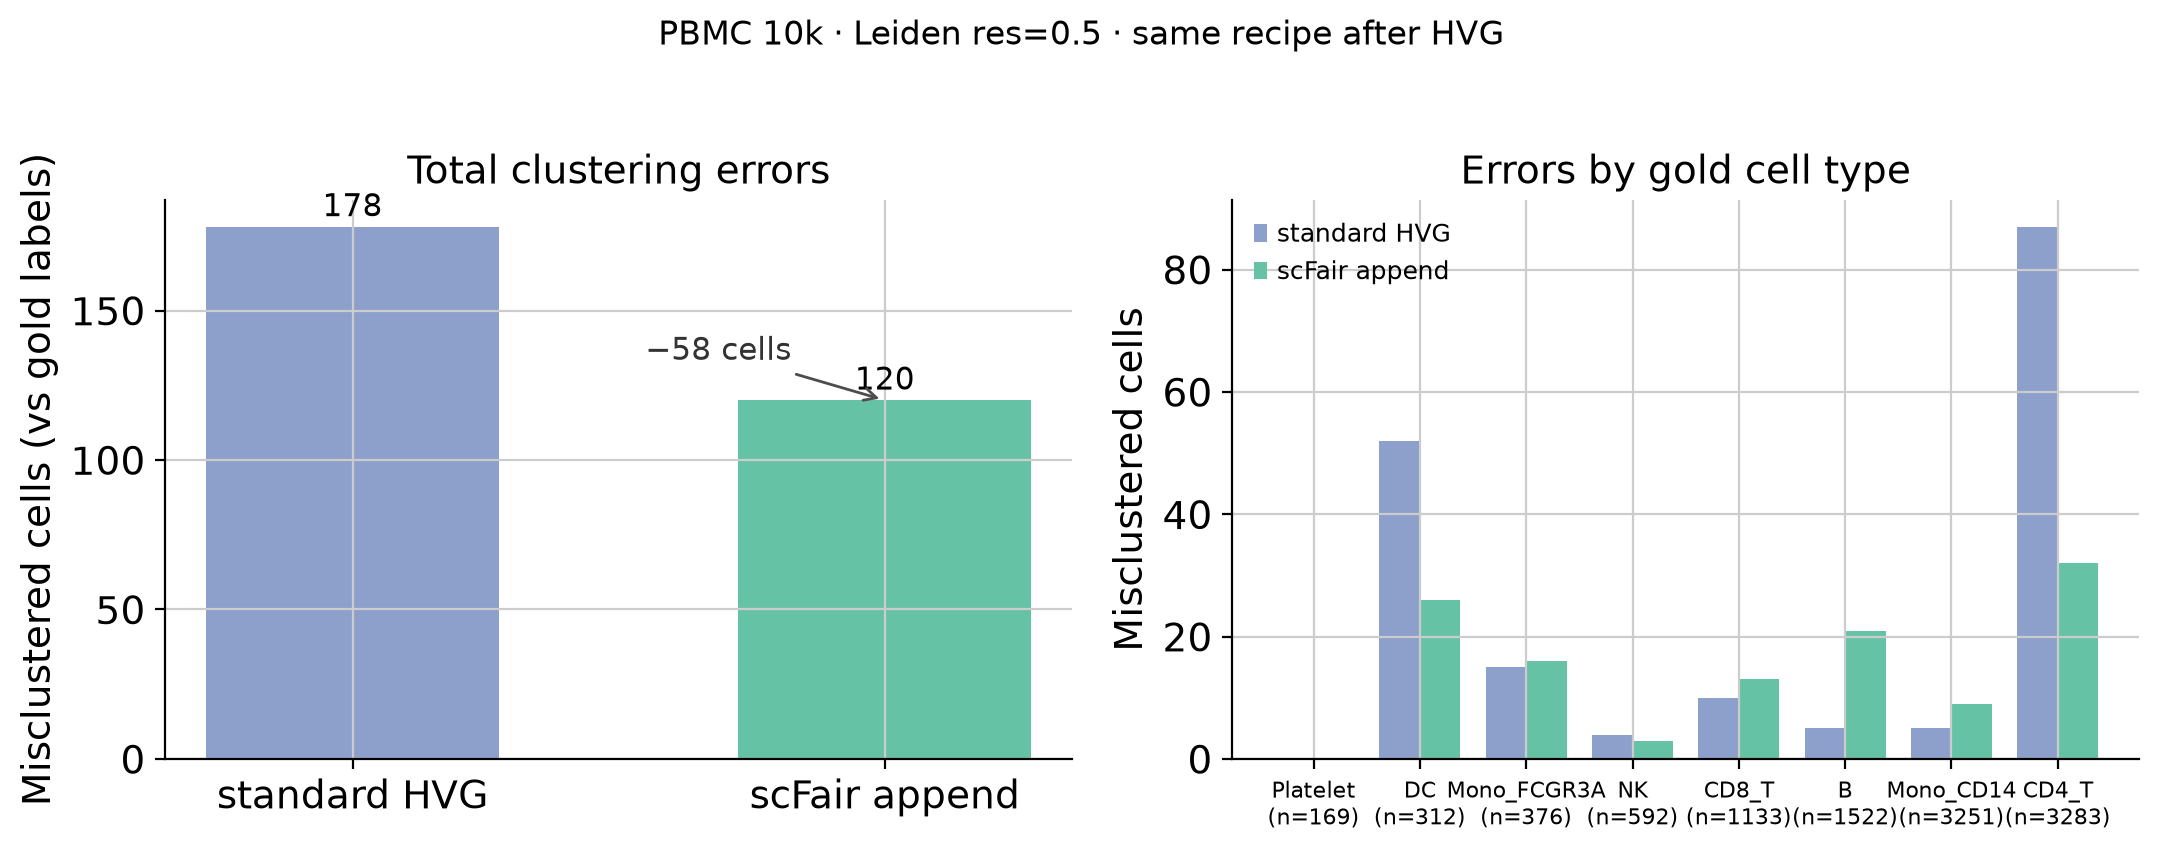

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

# Left: total misclustered cells
ax = axes[0]
methods = ["standard HVG", "scFair append"]
errs = [stats_std["n_misclustered"], stats_fair["n_misclustered"]]
colors = ["#8da0cb", "#66c2a5"]
bars = ax.bar(methods, errs, color=colors, width=0.55)
for b, e in zip(bars, errs):
    ax.text(b.get_x() + b.get_width() / 2, e + max(errs) * 0.02, str(e), ha="center", fontsize=11)
ax.set_ylabel("Misclustered cells (vs gold labels)")
ax.set_title("Total clustering errors")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if delta > 0:
    ax.annotate(
        f"−{delta} cells",
        xy=(1, errs[1]),
        xytext=(0.55, max(errs) * 0.75),
        arrowprops=dict(arrowstyle="->", color="0.3"),
        fontsize=11,
        color="0.2",
    )

# Right: per-type errors (small types first)
ax = axes[1]
x = np.arange(len(per))
w = 0.38
ax.bar(x - w / 2, per["err_standard"], w, label="standard HVG", color="#8da0cb")
ax.bar(x + w / 2, per["err_scfair"], w, label="scFair append", color="#66c2a5")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r.cell_type}\n(n={r.n_cells})" for r in per.itertuples()],
    fontsize=8,
)
ax.set_ylabel("Misclustered cells")
ax.set_title("Errors by gold cell type")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(
    f"PBMC 10k · Leiden res={RESOLUTION} · same recipe after HVG",
    y=1.02,
    fontsize=12,
)
fig.tight_layout()
plt.show()


## UMAP (context)

Embeddings are built from each method's own HVG list. Color by **gold**
`cell_type`, and a second pair marks cells that were misclustered under that
method's Leiden partition.


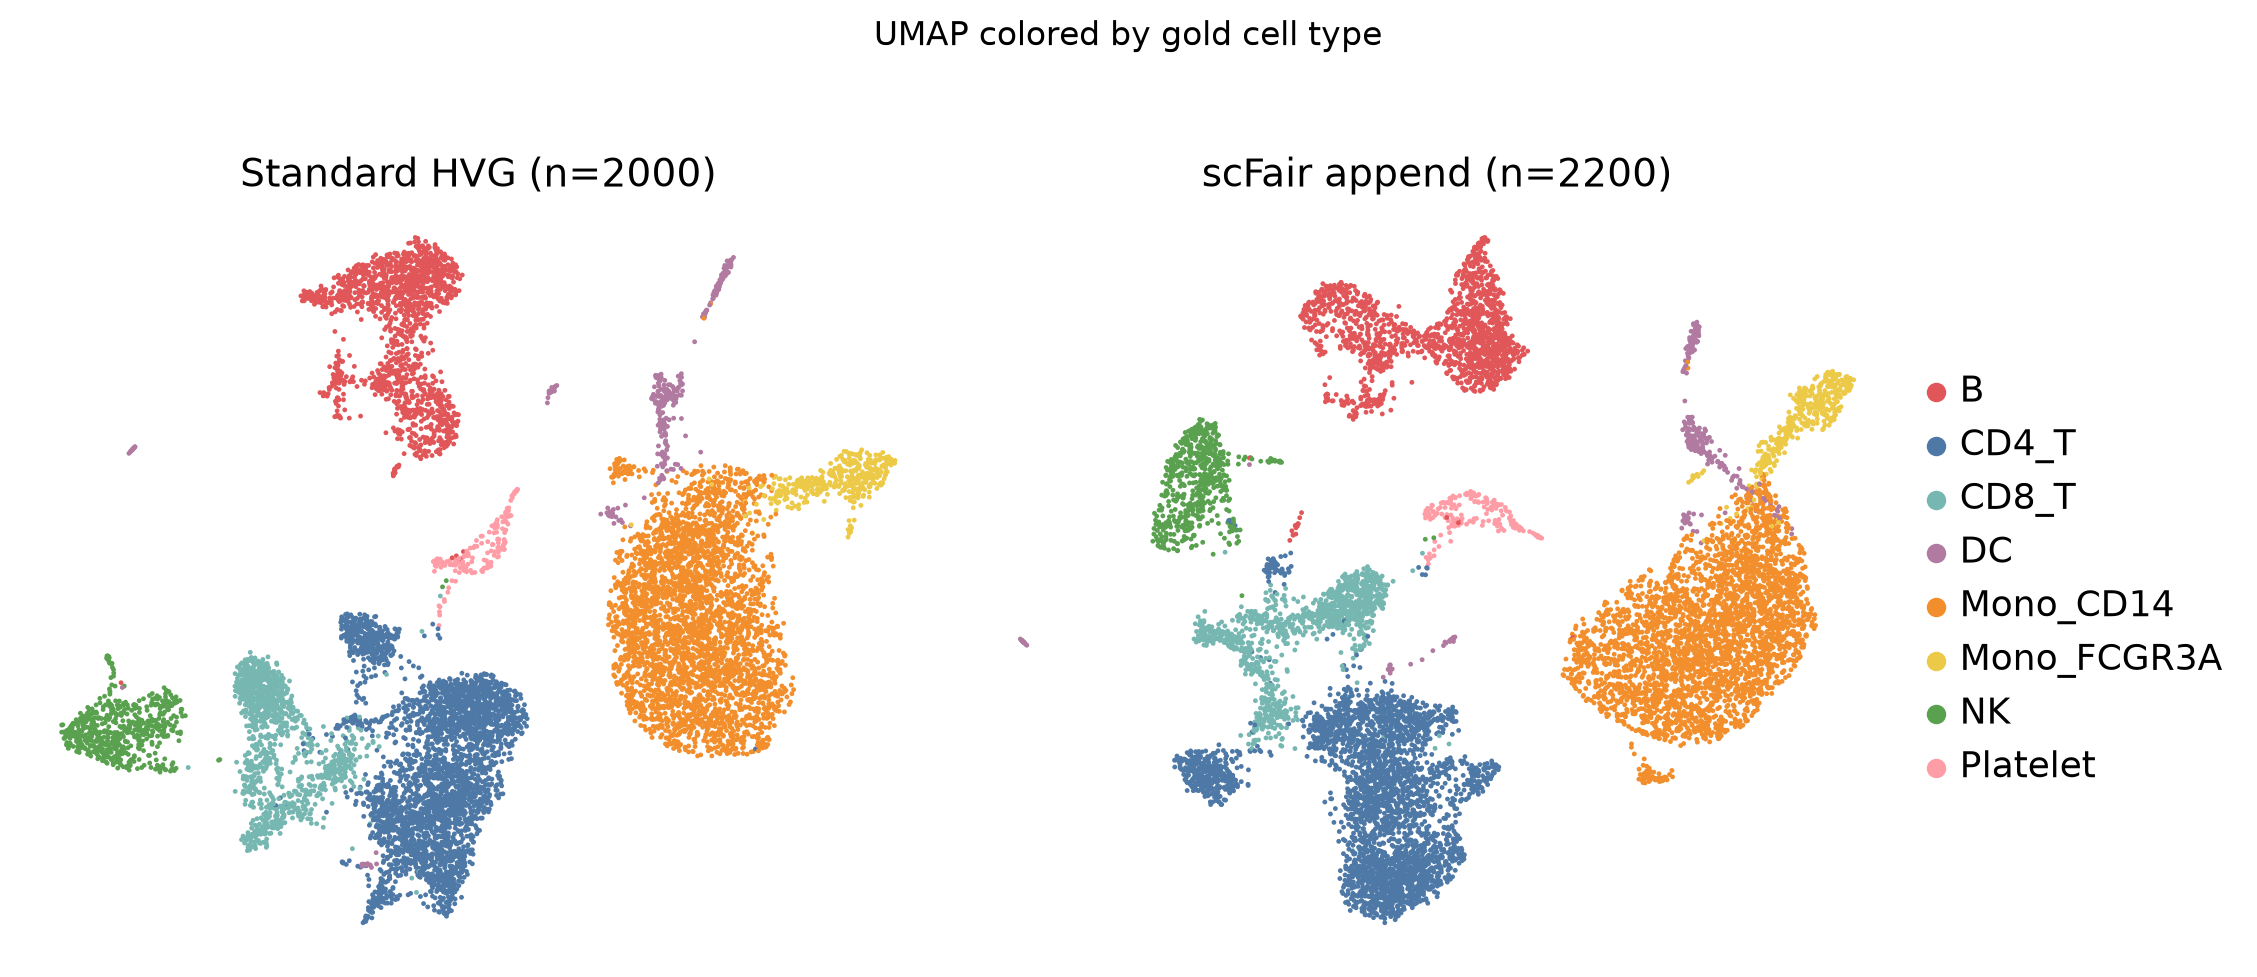

In [6]:
palette = {
    "CD4_T": "#4e79a7",
    "Mono_CD14": "#f28e2b",
    "B": "#e15759",
    "CD8_T": "#76b7b2",
    "NK": "#59a14f",
    "Mono_FCGR3A": "#edc948",
    "DC": "#b07aa1",
    "Platelet": "#ff9da7",
}
type_order = gold.value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, emb, title in [
    (axes[0], emb_std, f"Standard HVG (n={emb_std.uns['n_hvg']})"),
    (axes[1], emb_fair, f"scFair append (n={emb_fair.uns['n_hvg']})"),
]:
    sc.pl.umap(
        emb,
        color="cell_type",
        groups=type_order,
        palette=palette,
        ax=ax,
        show=False,
        title=title,
        frameon=False,
        legend_loc="right margin" if ax is axes[1] else "none",
        size=12,
    )
fig.suptitle("UMAP colored by gold cell type", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


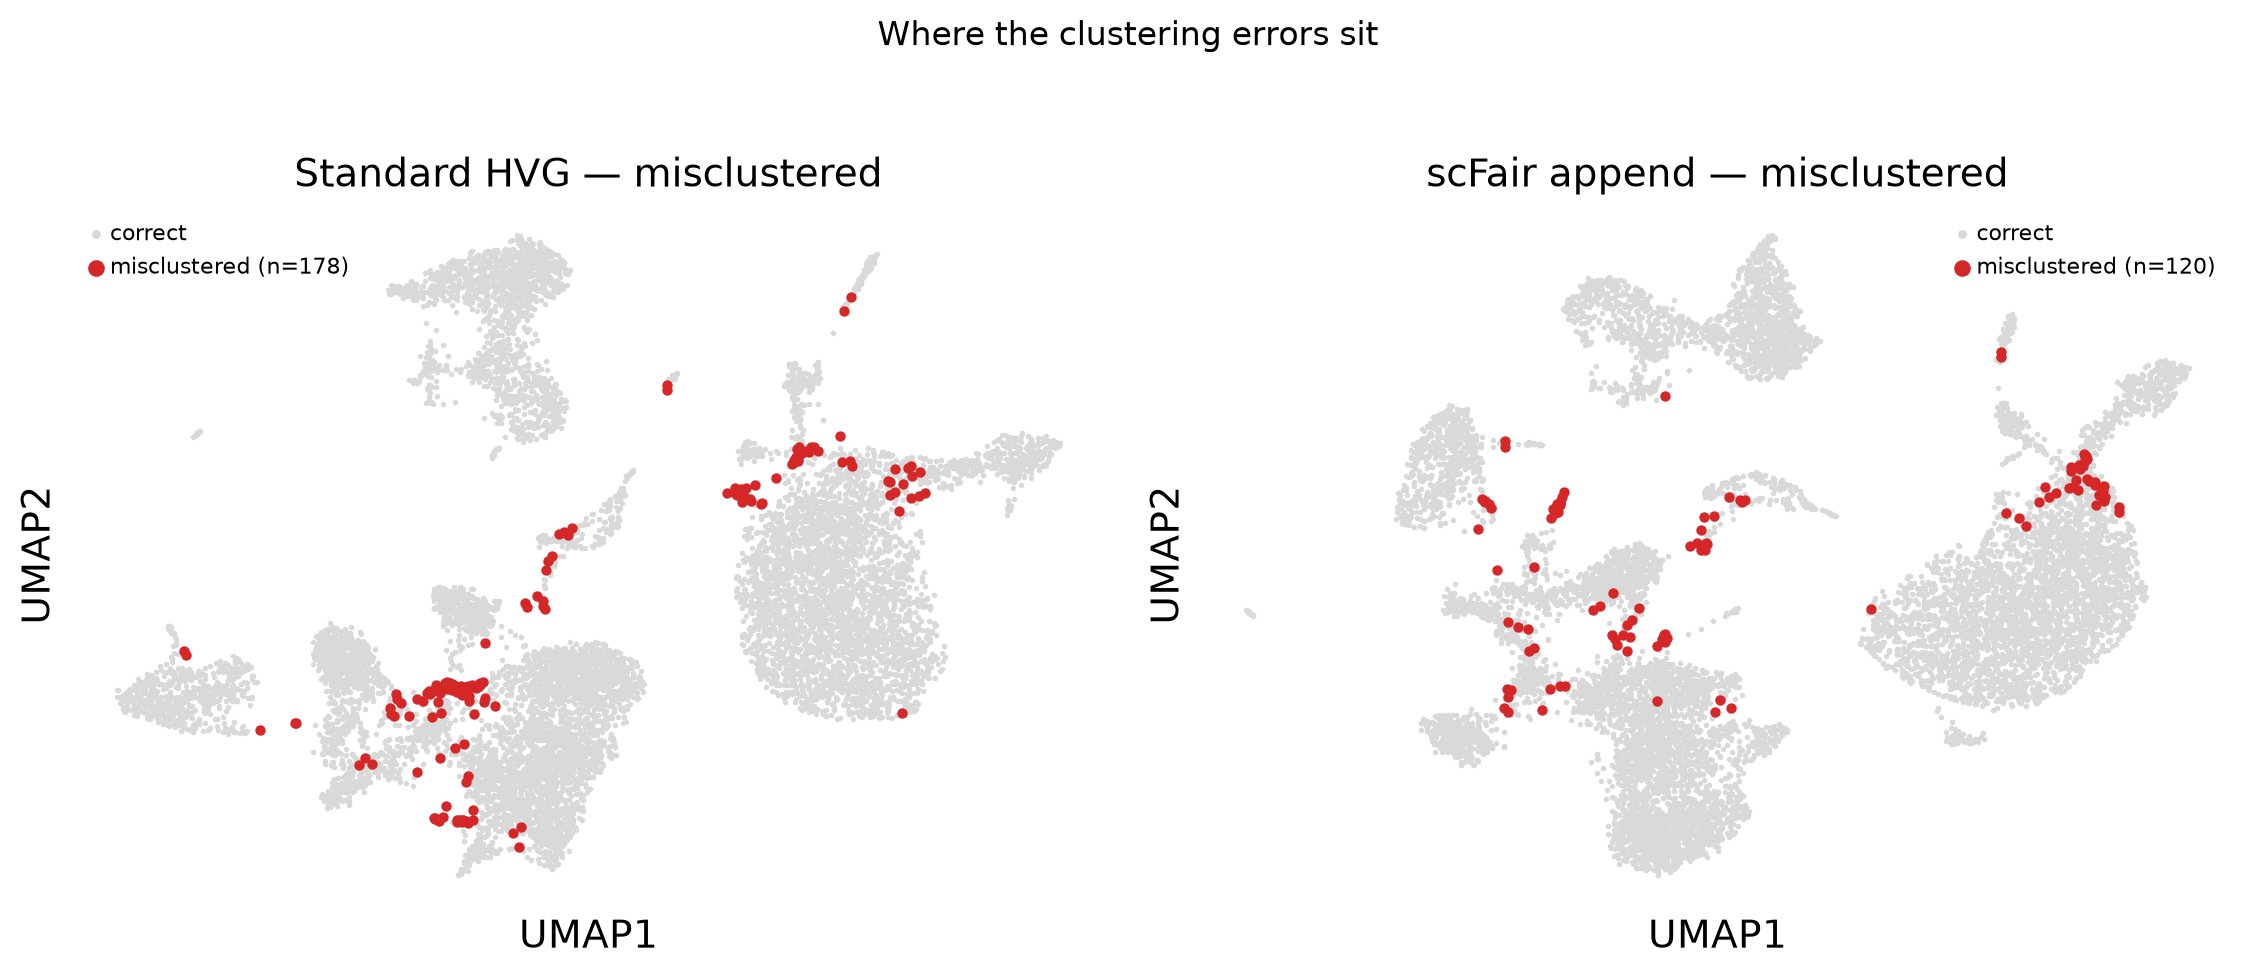

In [7]:
# Highlight misclustered cells on each UMAP
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, emb, st, title in [
    (axes[0], emb_std, stats_std, "Standard HVG — misclustered"),
    (axes[1], emb_fair, stats_fair, "scFair append — misclustered"),
]:
    xy = emb.obsm["X_umap"]
    ok = st["correct"]
    ax.scatter(xy[ok, 0], xy[ok, 1], s=4, c="0.85", linewidths=0, rasterized=True, label="correct")
    ax.scatter(
        xy[~ok, 0],
        xy[~ok, 1],
        s=14,
        c="#d62728",
        linewidths=0,
        rasterized=True,
        label=f"misclustered (n={st['n_misclustered']})",
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="best", markerscale=1.6)

fig.suptitle("Where the clustering errors sit", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


## How to read this

- **Headline number** — `n_misclustered` after majority-vote mapping to gold
  labels. Smaller is better. On this run, scFair cut the error count relative
  to standard HVG at the same Leiden resolution.
- **Per-type table** — errors often concentrate in smaller or hard-to-separate
  types (for example DC). That is where a longer, fairer HVG list helps most.
- **UMAP** — supports the counts; red points are cells whose Leiden cluster's
  majority gold label does not match their own gold label.
- **Not a universal scorecard** — results depend on the dataset, resolution,
  and label definition. Keep the recipe locked when you compare methods.

## Reproduce the comparison

```python
import scfair as scf
import scanpy as sc

# standard
scf.pp.highly_variable_genes(adata, n_top_genes=2000, balance_method="none")
# scFair default append
# scf.pp.highly_variable_genes(adata, n_top_genes=2000, balance_method="append")

adata = adata[:, adata.var["highly_variable"]].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", directed=False)
# then majority-vote map clusters → gold labels and count mismatches
```

See the [user guide](../user_guide/index.md) for HVG options and
`balance_method` choices.
